# Psycopg2 - Podstawy (DML i DQL)

**Psycopg2** = najpopularniejszy adapter PostgreSQL dla Pythona

- Piszemy **raw SQL** jako stringi
- Python API do wykonywania queries
- Bezpośrednia komunikacja z PostgreSQL
- Minimalna warstwa abstrakcji ("close to the metal")

**Kiedy używać psycopg2:**
- ✅ Proste CRUD operacje
- ✅ Potrzebujesz pełnej kontroli nad SQL
- ✅ Performance-critical queries
- ✅ Znasz SQL i nie potrzebujesz ORM

**Kiedy NIE używać psycopg2:**
- ❌ Skomplikowane relationships między tabelami
- ❌ Potrzebujesz automatic tracking zmian
- ❌ Chcesz pracować z obiektami Python zamiast SQL

Koncepcja konektora (adaptera) bazodanowego:

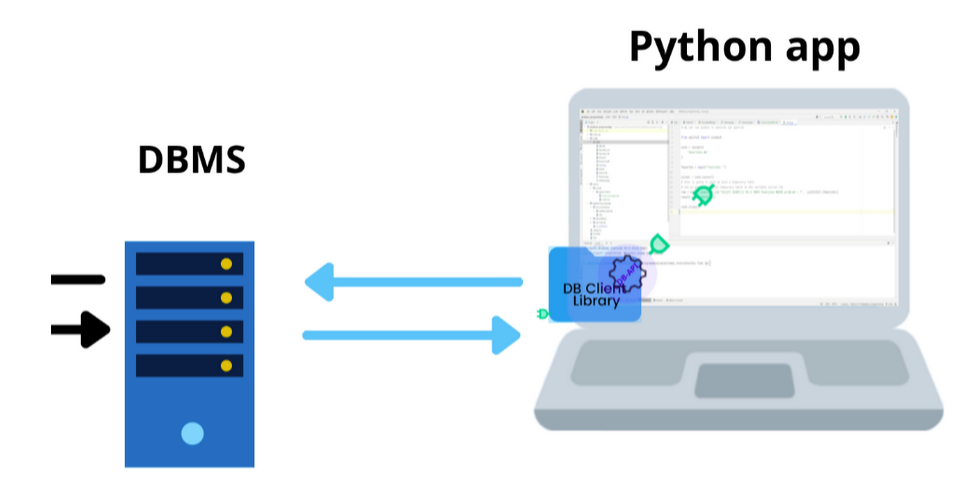

Pythonowy standard dla konektorów (adapterów) bazodanowych (**DBAPI**)
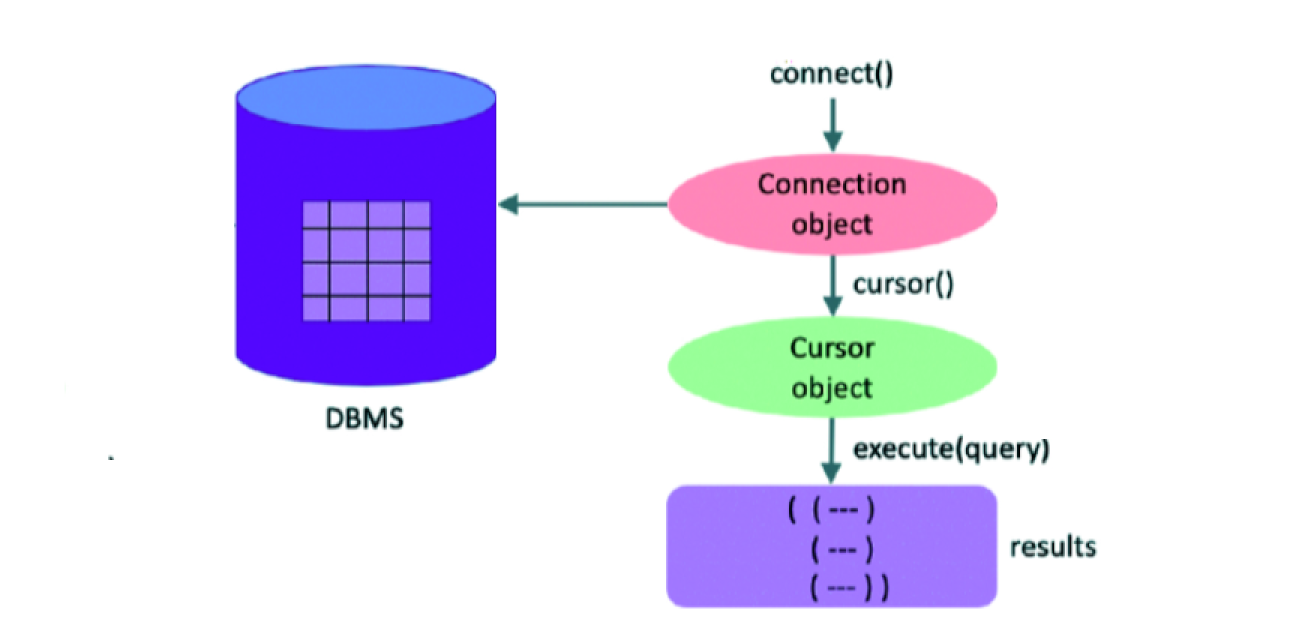

## Wymagania

### 1. Instalacja psycopg2

```bash
pip install psycopg2-binary
```

### 2. Uruchomienie PostgreSQL w Docker

**Krok 1: Przejdź do katalogu setup**
```bash
cd setup/
```

**Krok 2: Uruchom kontener PostgreSQL**
```bash
docker compose up -d
```

**Co robi ta komenda:**
- `docker compose up` - uruchamia serwisy zdefiniowane w `docker-compose.yml`
- `-d` (detached) - uruchamia w tle (nie blokuje terminala)

**Krok 3: Sprawdź czy kontener działa**
```bash
docker ps
```

Powinieneś zobaczyć kontener `fastapi-postgres` ze statusem `Up`.

**Przydatne komendy:**
```bash
# Zatrzymaj kontener
docker compose down

# Zatrzymaj i usuń dane (UWAGA: usunie wszystkie dane!)
docker compose down -v

# Logi kontenera (jeśli coś nie działa)
docker compose logs postgres

# Restart kontenera
docker compose restart
```

### 3. Parametry połączenia (z docker-compose.yml)

**Connection string:**
- Host: `localhost`
- Port: `5433` (mapowany z kontenera 5432)
- Database: `fastapi_db`
- User: `fastapi_user`
- Password: `fastapi_pass`

**Uwaga:** Port `5433` został użyty zamiast standardowego `5432`, żeby uniknąć konfliktu z lokalnym PostgreSQL (jeśli masz zainstalowany).

## Połączenie z bazą

**Context manager (`with`) - dlaczego?**

Bez context manager:
```python
conn = psycopg2.connect(...)
cursor = conn.cursor()
cursor.execute("SELECT ...")
cursor.close()  # Musimy pamiętać!
conn.close()    # Musimy pamiętać!
```

**Problemy:**
- ❌ Łatwo zapomnieć o `.close()` (connection/cursor leak!)
- ❌ Jeśli exception - połączenie nie zostanie zamknięte
- ❌ Więcej kodu (boilerplate)

Z context manager:
```python
with psycopg2.connect(...) as conn:
    with conn.cursor() as cursor:
        cursor.execute("SELECT ...")
        # Automatyczne zamknięcie cursor i conn!
```

**Co zyskujemy:**
- ✅ Automatyczne zamknięcie connection i cursor
- ✅ Exception-safe (cleanup nawet przy błędzie)
- ✅ Czytelniejszy kod
- ✅ **Auto-commit przy wyjściu z `with conn:`** (jeśli sukces)
- ✅ **Auto-rollback** (jeśli exception)

**WAŻNE: Context manager robi auto-commit!**

```python
with psycopg2.connect(...) as conn:
    cursor.execute("INSERT ...")
    # Przy wyjściu z `with` → automatyczny COMMIT (jeśli sukces)
    # Przy exception → automatyczny ROLLBACK
```

**Czy potrzebne jest `conn.commit()`?**

Technicznie **NIE**, bo context manager zrobi to automatycznie. Ale wielu programistów robi to **jawnie** dla jasności:

```python
with psycopg2.connect(...) as conn:
    cursor.execute("INSERT ...")
    conn.commit()  # Jawny commit (explicit is better than implicit)
```

**Bez context manager - MUSISZ robić commit:**

```python
conn = psycopg2.connect(...)
cursor.execute("INSERT ...")
conn.commit()  # ← KONIECZNE! Inaczej zmiany NIE zostaną zapisane
conn.close()
```

In [ ]:
import psycopg2

# Parametry połączenia (z docker-compose.yml)
DB_CONFIG = {
    "host": "localhost",
    "port": 5433,
    "database": "fastapi_db",
    "user": "fastapi_user",
    "password": "fastapi_pass"
}

# Test połączenia
with psycopg2.connect(**DB_CONFIG) as conn:
    print(f"Połączono z bazą: {conn.info.dbname}")
    print(f"Status: {conn.info.status}")
    print(f"Server version: {conn.info.server_version}")

## Tworzenie tabeli

**DDL (Data Definition Language)** = SQL do tworzenia struktur bazy (CREATE TABLE, DROP TABLE, ALTER TABLE)

**Uwaga:** W psycopg2 piszemy raw SQL jako stringi.

In [ ]:
# Tworzymy tabelę task
CREATE_TABLE_SQL = """
CREATE TABLE IF NOT EXISTS task (
    id SERIAL PRIMARY KEY,
    name VARCHAR(100) NOT NULL
);
"""

with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(CREATE_TABLE_SQL)
        conn.commit()
        print("Tabela 'task' utworzona!")

In [ ]:
# Opcjonalnie: DROP TABLE (jeśli chcesz zacząć od nowa)
DROP_TABLE_SQL = "DROP TABLE IF EXISTS task;"

with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(DROP_TABLE_SQL)
        conn.commit()
        print("Tabela 'task' usunięta!")
        
# Tworzymy ponownie
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(CREATE_TABLE_SQL)
        conn.commit()
        print("Tabela 'task' utworzona ponownie!")

## C - CREATE (CRUD) - DML (Data Manipulation Language)

**DML** = SQL do manipulacji danymi (INSERT, UPDATE, DELETE)

**Cursor** = obiekt do wykonywania SQL queries
- `.execute(sql)` - wykonuje query
- `.fetchone()` - pobiera jeden wiersz
- `.fetchall()` - pobiera wszystkie wiersze
- `.fetchmany(n)` - pobiera n wierszy

### INSERT - dodawanie danych

**Parametryzacja queries - ZAWSZE używaj %s!**

❌ **ŹLE (SQL injection risk!):**
```python
cursor.execute(f"INSERT INTO task (name) VALUES ('{name}')")
```

✅ **DOBRZE (bezpieczne):**
```python
cursor.execute("INSERT INTO task (name) VALUES (%s)", (name,))
```

**Dlaczego %s, a nie %d czy %f?**
- Psycopg2 sam konwertuje typy Python → PostgreSQL
- ZAWSZE używaj `%s` (nawet dla int, float, bool)
- Psycopg2 escapuje wartości (bezpieczeństwo)

In [ ]:
# INSERT jednego wiersza
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(
            "INSERT INTO task (name) VALUES (%s)",
            ("Sprzątanie",)  # Uwaga: tuple (nawet dla 1 elementu!)
        )
        conn.commit()
        print("Dodano task: Sprzątanie")

In [ ]:
# INSERT z RETURNING (PostgreSQL feature)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(
            "INSERT INTO task (name) VALUES (%s) RETURNING id",
            ("Pisanie",)
        )
        new_id = cursor.fetchone()[0]
        conn.commit()
        print(f"Dodano task: Pisanie, ID: {new_id}")

In [ ]:
# INSERT wielu wierszy naraz (executemany)
tasks = [
    ("Zamiatanie",),
    ("Malowanie",),
    ("Szukanie",),
    ("Programowanie",),
]

with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.executemany(
            "INSERT INTO task (name) VALUES (%s)",
            tasks
        )
        conn.commit()
        print(f"Dodano {cursor.rowcount} tasków")

In [ ]:
# Dodajmy więcej tasków do analizy
more_tasks = [
    ("Szukanie",),  # duplikat (testowanie)
    ("Pływanie",),
    ("Pranie",),
    ("Dodawanie",),
]

with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.executemany(
            "INSERT INTO task (name) VALUES (%s)",
            more_tasks
        )
        conn.commit()
        print(f"Dodano {cursor.rowcount} tasków")

## R - READ (CRUD) - DQL (Data Query Language)

**DQL** = SQL do pobierania danych (SELECT)

**Metody pobierania wyników:**
- `.fetchone()` - jeden wiersz (tuple)
- `.fetchall()` - wszystkie wiersze (lista tupli)
- `.fetchmany(n)` - n wierszy (lista tupli)
- Iteracja: `for row in cursor:`

In [ ]:
# SELECT - wszystkie wiersze
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute("SELECT * FROM task")
        rows = cursor.fetchall()
        
        print(f"Pobrano {len(rows)} wierszy\n")
        print("Wszystkie taski:")
        for row in rows:
            print(f"  ID: {row[0]}, Name: {row[1]}")

In [ ]:
# SELECT - jeden wiersz (fetchone)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute("SELECT * FROM task WHERE id = %s", (1,))
        row = cursor.fetchone()
        
        if row:
            print(f"Znaleziono: ID={row[0]}, Name={row[1]}")
        else:
            print("Nie znaleziono")

### RealDictCursor - dostęp do kolumn po nazwie

**Problem z domyślnym cursor:**
```python
row = (1, 'Sprzątanie')  # Tuple - dostęp po indeksie
row[0]  # ID
row[1]  # Name
```

**Rozwiązanie: RealDictCursor**
```python
row = {'id': 1, 'name': 'Sprzątanie'}  # Dict
row['id']    # ID
row['name']  # Name
```

✅ **Zalety:**
- Czytelniejszy kod
- Łatwiejsze debugowanie
- Lepsze dla JSON API

In [ ]:
from psycopg2.extras import RealDictCursor

# RealDictCursor - zwraca dict zamiast tuple
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task LIMIT 3")
        rows = cursor.fetchall()
        
        print("Taski (dict):")
        for row in rows:
            print(f"  ID: {row['id']}, Name: {row['name']}")
            print(f"  Type: {type(row)}")

### WHERE - filtrowanie

**ZAWSZE używaj parametryzacji (%s)!**

In [ ]:
# WHERE - równość
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute(
            "SELECT * FROM task WHERE name = %s",
            ("Szukanie",)
        )
        rows = cursor.fetchall()
        
        print(f"Znaleziono {len(rows)} tasków 'Szukanie':")
        for row in rows:
            print(f"  {row}")

In [ ]:
# WHERE LIKE (wyszukiwanie wzorca)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute(
            "SELECT * FROM task WHERE name LIKE %s",
            ("%wanie",)  # Kończy się na 'wanie'
        )
        rows = cursor.fetchall()
        
        print("Taski kończące się na 'wanie':")
        for row in rows:
            print(f"  {row['name']}")

In [ ]:
# WHERE IN (lista wartości)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute(
            "SELECT * FROM task WHERE name IN (%s, %s, %s)",
            ("Malowanie", "Szukanie", "Pływanie")
        )
        rows = cursor.fetchall()
        
        print("Taski z listy:")
        for row in rows:
            print(f"  {row['name']}")

In [ ]:
# WHERE z porównaniami (>, <, >=, <=)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        # >
        cursor.execute("SELECT * FROM task WHERE id > %s", (5,))
        rows = cursor.fetchall()
        print(f"ID > 5: {len(rows)} wyników")
        
        # <=
        cursor.execute("SELECT * FROM task WHERE id <= %s", (4,))
        rows = cursor.fetchall()
        print(f"ID <= 4: {len(rows)} wyników")

### AND / OR - łączenie warunków

In [ ]:
# AND - wiele warunków
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute(
            "SELECT * FROM task WHERE name LIKE %s AND id >= %s",
            ("%wanie", 6)
        )
        rows = cursor.fetchall()
        
        print("AND (name LIKE '%wanie' AND id >= 6):")
        for row in rows:
            print(f"  {row}")

In [ ]:
# OR - alternatywa
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute(
            "SELECT * FROM task WHERE name LIKE %s OR id >= %s",
            ("%wanie", 6)
        )
        rows = cursor.fetchall()
        
        print("OR (name LIKE '%wanie' OR id >= 6):")
        for row in rows:
            print(f"  {row}")

### ORDER BY - sortowanie

In [ ]:
# ORDER BY (rosnąco)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task ORDER BY name")
        rows = cursor.fetchall()
        
        print("ORDER BY name (ASC):")
        for row in rows:
            print(f"  {row['name']}")

In [ ]:
# ORDER BY DESC (malejąco)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task ORDER BY name DESC")
        rows = cursor.fetchall()
        
        print("ORDER BY name DESC:")
        for row in rows:
            print(f"  {row['name']}")

### LIMIT / OFFSET - paginacja

In [ ]:
# LIMIT - ograniczenie liczby wyników
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task ORDER BY name LIMIT 5")
        rows = cursor.fetchall()
        
        print("LIMIT 5:")
        for row in rows:
            print(f"  {row}")

In [ ]:
# OFFSET + LIMIT (paginacja)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task ORDER BY id OFFSET 3 LIMIT 3")
        rows = cursor.fetchall()
        
        print("OFFSET 3 LIMIT 3 (taski 4-6):")
        for row in rows:
            print(f"  {row}")

## U - UPDATE (CRUD)

**UPDATE** = modyfikacja istniejących wierszy

**UWAGA:** ZAWSZE używaj WHERE! Bez WHERE zaktualizujesz WSZYSTKIE wiersze!

In [ ]:
# UPDATE - zmiana jednego wiersza
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(
            "UPDATE task SET name = %s WHERE id = %s",
            ("Sprzątanie (zaktualizowane)", 1)
        )
        conn.commit()
        print(f"Zaktualizowano {cursor.rowcount} wierszy")

In [ ]:
# Weryfikacja UPDATE
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task WHERE id = %s", (1,))
        row = cursor.fetchone()
        print(f"Po UPDATE: {row}")

In [ ]:
# UPDATE - wiele wierszy (WHERE z warunkiem)
# Operator || - konkatenacja stringów (PostgreSQL i SQL standard ANSI)
# name || ' (zrobione)' → łączy wartość name z tekstem ' (zrobione)'
# Przykład: 'Malowanie' || ' (zrobione)' → 'Malowanie (zrobione)'
#
# Inne bazy danych:
# - PostgreSQL, Oracle, SQLite: || (operator konkatenacji)
# - MySQL: CONCAT(name, ' (zrobione)') lub || w trybie ANSI
# - MSSQL Server: name + ' (zrobione)' (operator +)

with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(
            "UPDATE task SET name = name || ' (zrobione)' WHERE name LIKE %s",
            ("%wanie",)
        )
        conn.commit()
        print(f"Zaktualizowano {cursor.rowcount} wierszy")

In [ ]:
# Weryfikacja UPDATE (multiple)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task WHERE name LIKE %s", ("%zrobione%",))
        rows = cursor.fetchall()
        
        print("Zaktualizowane taski:")
        for row in rows:
            print(f"  {row['name']}")

## D - DELETE (CRUD)

**DELETE** = usuwanie wierszy

**UWAGA:** ZAWSZE używaj WHERE! Bez WHERE usuniesz WSZYSTKIE wiersze!

In [ ]:
# DELETE - usunięcie jednego wiersza
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(
            "DELETE FROM task WHERE id = %s",
            (1,)
        )
        conn.commit()
        print(f"Usunięto {cursor.rowcount} wierszy")

In [ ]:
# Weryfikacja DELETE
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task WHERE id = %s", (1,))
        row = cursor.fetchone()
        print(f"Po DELETE: {row}")  # None (nie znaleziono)

In [ ]:
# DELETE - wiele wierszy (WHERE z warunkiem)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute(
            "DELETE FROM task WHERE name LIKE %s",
            ("%zrobione%",)
        )
        conn.commit()
        print(f"Usunięto {cursor.rowcount} wierszy")

In [ ]:
# Weryfikacja DELETE (multiple)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task")
        rows = cursor.fetchall()
        
        print(f"Pozostało {len(rows)} tasków:")
        for row in rows:
            print(f"  {row}")

## Transakcje - commit i rollback

**Transakcja** = grupa operacji SQL wykonywana atomowo (wszystkie albo żadna)

**Zachowanie context manager:**

```python
with psycopg2.connect(...) as conn:
    cursor.execute("INSERT ...")
    cursor.execute("UPDATE ...")
    # Przy wyjściu z `with`:
    # ✅ Sukces (brak exception) → automatyczny COMMIT
    # ❌ Exception → automatyczny ROLLBACK
```

**Jawny commit (opcjonalny, ale zalecany dla jasności):**

```python
with psycopg2.connect(...) as conn:
    cursor.execute("INSERT ...")
    conn.commit()  # Explicit commit (dobra praktyka)
```

**Rollback przy exception:**

```python
try:
    with psycopg2.connect(...) as conn:
        cursor.execute("INSERT ...")
        raise Exception("Błąd!")  # Auto rollback!
except Exception:
    pass  # Transakcja wycofana
```

**Jawny rollback (jeśli potrzebujesz rollback BEZ exception):**

```python
with psycopg2.connect(...) as conn:
    cursor.execute("INSERT ...")
    
    if some_condition:
        conn.rollback()  # Ręczny rollback
    else:
        conn.commit()    # Commit
```

In [ ]:
# Transakcja - sukces (commit)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor() as cursor:
        cursor.execute("INSERT INTO task (name) VALUES (%s)", ("Task 1",))
        cursor.execute("INSERT INTO task (name) VALUES (%s)", ("Task 2",))
        conn.commit()  # Explicit commit
        print("Transakcja zakończona sukcesem (commit)")

In [ ]:
# Transakcja - rollback (przy exception)
try:
    with psycopg2.connect(**DB_CONFIG) as conn:
        with conn.cursor() as cursor:
            cursor.execute("INSERT INTO task (name) VALUES (%s)", ("Task 3",))
            cursor.execute("INSERT INTO task (name) VALUES (%s)", ("Task 4",))
            
            # Symulacja błędu
            raise Exception("Coś poszło nie tak!")
            
            conn.commit()  # Nie wykona się (exception)
except Exception as e:
    print(f"Transakcja wycofana (rollback): {e}")

In [ ]:
# Weryfikacja - Task 3 i Task 4 nie zostały dodane (rollback)
with psycopg2.connect(**DB_CONFIG) as conn:
    with conn.cursor(cursor_factory=RealDictCursor) as cursor:
        cursor.execute("SELECT * FROM task WHERE name IN (%s, %s)", ("Task 3", "Task 4"))
        rows = cursor.fetchall()
        
        if not rows:
            print("Task 3 i Task 4 NIE zostały dodane (rollback zadziałał!)")
        else:
            print(f"Znaleziono: {rows}")

## 📝 Podsumowanie: Psycopg2

**Co zrobiliśmy:**
- ✅ Połączenie z PostgreSQL (context manager)
- ✅ CREATE TABLE (DDL)
- ✅ INSERT (pojedyncze i multiple)
- ✅ SELECT (fetchone, fetchall)
- ✅ WHERE (filtering)
- ✅ Operatory: `=`, `LIKE`, `IN`, `>`, `<`, `>=`, `<=`
- ✅ AND/OR (łączenie warunków)
- ✅ ORDER BY (sortowanie)
- ✅ LIMIT/OFFSET (paginacja)
- ✅ UPDATE (modyfikacja)
- ✅ DELETE (usuwanie)
- ✅ Transakcje (commit/rollback)
- ✅ RealDictCursor (dostęp po nazwie kolumny)

**Dlaczego context manager (`with`):**
- ✅ Automatyczne zamknięcie connection i cursor
- ✅ Exception-safe (auto rollback przy błędzie)
- ✅ Auto-commit przy sukcesie (wyjście z `with conn:`)
- ✅ Czytelniejszy kod
- ✅ Zapobiega connection/cursor leaks

**ZAWSZE pamiętaj:**
- ⚠️ **Parametryzacja queries** (`%s`, NIGDY f-strings!) - bezpieczeństwo przed SQL injection
- ⚠️ **WHERE w UPDATE/DELETE** (bez WHERE = wszystkie wiersze!)
- ⚠️ **conn.commit()** opcjonalne w `with conn:`, ale zalecane dla jasności (explicit is better than implicit)

**Zalety psycopg2:**
- ✅ Prosty (raw SQL)
- ✅ Wydajny (minimalna warstwa abstrakcji)
- ✅ Pełna kontrola nad SQL
- ✅ Idealny do prostych CRUD
- ✅ Bezpośredni dostęp do PostgreSQL features (RETURNING, array types, JSON, etc.)

**Wady psycopg2:**
- ❌ SQL jako stringi (łatwo o błędy składniowe)
- ❌ Brak type safety (Python nie sprawdza SQL)
- ❌ Brak relationships (trzeba JOIN ręcznie)
- ❌ Brak automatic tracking zmian
- ❌ Brak identity map (każde query = nowe tuple/dict)
- ❌ Brak lazy loading

**Kiedy używać:**
- ✅ Proste CRUD operacje
- ✅ Performance-critical queries (minimal overhead)
- ✅ Znasz SQL i nie potrzebujesz abstrakcji
- ✅ Potrzebujesz specyficznych PostgreSQL features

**Kiedy NIE używać:**
- ❌ Skomplikowane relationships między tabelami
- ❌ Potrzebujesz ORM features (lazy loading, identity map, automatic tracking)
- ❌ Wolisz pracować z obiektami Python zamiast raw SQL
- ❌ Chcesz database-agnostic code (przenośność między MySQL/PostgreSQL/SQLite)

**Następny krok:**
- **SQLAlchemy Core** - SQL w Pythonie (bez ORM), database-agnostic, type-safe
- **SQLAlchemy ORM** - klasy Python, relationships, lazy loading, identity map, automatic tracking